# Dog Re-Identification — Two-Stage Siamese Training

## 🧠 Problem definition (ReID vs classification)

A user has lost their dog. They upload a photo. We want to find that *exact* dog among
the photos in our shelter database.

This is **re-identification** (ReID), **not** classification:

| | Classification | ReID |
|---|---|---|
| Goal | Predict a fixed label set (e.g., breed) | Match an *unknown* identity to a gallery |
| Train classes = test classes? | Yes | **No** — test dogs are never seen during training |
| Output | A class probability | A similarity score against every gallery item |
| Metric | Accuracy | Rank-1 / Rank-5 / mAP |

We learn an **embedding space** in which photos of the *same* dog are close, photos of
*different* dogs are far. At inference we cosine-search the user's photo against the
shelter gallery.

## 🚨 Why the previous version stagnated

Symptom you observed: training loss got stuck around **0.21**.

Root causes (each addressed in this notebook):

1. The triplets were too easy → most had loss = 0 → no learning signal.
2. The projector started cold from random weights → had to learn breed-level features
   *and* identity features simultaneously from very few triplets.
3. The cosine LR schedule decayed the LR before the model had converged.
4. Embedding size 128 was small for distinguishing thousands of individual dogs.
5. Augmentations were minimal → the model didn't see enough viewpoint variance.

## 🚀 Solution: a two-stage curriculum

```
Stage 1 — Pretraining on Stanford Dogs (breed classification, 3-5 epochs)
   ↓ (drop the classifier head, keep the projector)
Stage 2 — Fine-tuning on PetFinder (triplet ReID with semi-hard mining)
```

Stage 1 gives the projector strong dog-aware features for free. Stage 2 then only has
to learn *individual identity* on top of breed-aware features — much easier to optimise.

## ⚙️ Stack & constraints

- **Backbone**: CLIP ViT-B/32, fully frozen. Discussed below.
- **Embedding dim**: 256 (was 128).
- **Pretraining**: Stanford Dogs (120 breeds, ~20 K images), via Kaggle "Add Data".
- **Fine-tuning**: PetFinder dogs only, multi-photo triplets.
- **Loss**: Triplet margin loss with cosine distance + semi-hard negative mining.

### Why keep CLIP frozen?

Unfreezing the last CLIP blocks would help, but it would force us to ship the modified
CLIP weights as a new artefact (e.g. `dog_clip_finetuned.pt`), updating
`backend/dog_finder.py` accordingly. To preserve full backward compatibility with the
existing chatbot backend (only `dog_encoder.pt`, `dog_emb_reid.npy`, `dog_ids_reid.npy`
are exported), we leave CLIP frozen. The Stanford Dogs pretraining gives us most of the
benefit a partial unfreeze would give, at zero compatibility cost.

## 📦 Dataset roles

- **PetFinder Adoption Prediction** — main data (chatbot domain). Each dog has 1-N photos
  named `{PetID}-{n}.jpg`. We use this for **triplet ReID training and final export**.
  Limitation: most dogs have only 1-3 photos, often near-identical → modest identity
  signal. This is *the* reason we need pretraining.

- **Stanford Dogs** — auxiliary data (pretraining only). 120 breeds × ~150 images per
  breed. We use it to teach the projector "which images depict similar-looking dogs"
  before we even start ReID.

## 📤 Final exports (unchanged file names)

| File              | Format            | Used by                                |
|-------------------|-------------------|----------------------------------------|
| `dog_encoder.pt`  | projector state_dict | `backend/tools/dog_finder.py` (Siamese) |
| `dog_emb_reid.npy`| `(N, 256)` float32 | FAISS gallery |
| `dog_ids_reid.npy`| `(N,)` object      | PetID lookup |


---
## 0 — Installation


In [18]:
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q tqdm matplotlib


  Preparing metadata (setup.py) ... done


---
## 1 — Config

All hyperparameters and paths are gathered here so a future tweak (e.g. more pretraining
epochs, a different margin) is a one-place change. Touching constants outside this cell
is a code smell — fix the constants here instead.


In [19]:
from pathlib import Path

base_path = Path("/kaggle/input/datasets/jessicali9530")

for p in base_path.iterdir():
    if p.is_dir():
        print(p.name)

stanford-dogs-dataset


In [20]:
# ── Paths ──────────────────────────────────────────────────────────────────
PETFINDER_IMAGES = "/kaggle/input/competitions/petfinder-adoption-prediction/train_images"
PETFINDER_CSV    = "/kaggle/input/competitions/petfinder-adoption-prediction/train/train.csv"

# Stanford Dogs — auto-detected at load time, common Kaggle paths tried in order.
STANFORD_PATHS = [
    "/kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images",   # chemin correct (priorité 1)
    "/kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/Images",
    "/kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images",
    "/kaggle/input/datasets/jessicali9530/stanford-dogs-dataset",
]

OUTPUT_DIR = "/kaggle/working/artifacts"

# ── Model ──────────────────────────────────────────────────────────────────
CLIP_DIM    = 512   # ViT-B/32 image-encoder output dim — fixed by CLIP
EMBED_DIM   = 256   # Projector output dim. MUST match SIAMESE_DIM in backend/tools/dog_finder.py.

# ── Stage 1 — Stanford Dogs pretraining ───────────────────────────────────
PRETRAIN_EPOCHS    = 10
PRETRAIN_LR        = 1e-3
PRETRAIN_BATCH     = 64
PRETRAIN_NUM_WORKERS = 0

# ── Stage 2 — PetFinder triplet ReID ───────────────────────────────────────
N_EPOCHS    = 20
N_TRIPLETS  = 12_000   # synthetic triplets per epoch
BATCH_SIZE  = 32
MARGIN      = 0.3      # cosine-distance margin for triplet loss
LR          = 1e-4     # constant — no scheduler (see markdown rationale)
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 3   # epochs with no loss improvement → stop

# ── Eval split ──────────────────────────────────────────────────────────────
VAL_FRACTION = 0.15
SEED         = 42

# ── Reproducibility ─────────────────────────────────────────────────────────
import random as _r
import numpy as _np
import torch as _t
_r.seed(SEED); _np.random.seed(SEED); _t.manual_seed(SEED)
if _t.cuda.is_available():
    _t.cuda.manual_seed_all(SEED)


In [21]:
!pip install -q faiss-cpu

---
## 2 — Imports


In [22]:
import os
import time
from pathlib import Path
from collections import defaultdict
from typing import Optional

import clip
import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


---
## 3 — Model: frozen CLIP + trainable projector

The projector's job is to map CLIP's general 512-d image features into a 256-d space
*specifically tuned for dog identity*. We keep CLIP frozen for two reasons:

1. **Compatibility**: only the projector is shipped to the backend (`dog_encoder.pt`).
2. **Training cost**: CLIP has ~88 M params, the projector ~400 K. Freezing CLIP cuts
   the backward pass to a fraction of the cost.

### Projector architecture

```
Linear(512, 512) → BatchNorm1d → GELU → Dropout(0.1) → Linear(512, 256) → L2-normalize
```

- Wider hidden layer (512 → 512) gives the projector enough capacity to encode breed
  *and* identity features.
- GELU instead of ReLU: smoother gradients on the high-dimensional CLIP features.
- L2-normalisation at output → cosine similarity ≡ dot product → FAISS `IndexFlatIP`.

> ⚠️ The exact same architecture lives in `backend/tools/dog_finder.py::_load_siamese`.
> If you change one, change both.


In [23]:
class Projector(nn.Module):
    """CLIP -> dog-identity 256-d space."""

    def __init__(self, in_dim: int = CLIP_DIM, out_dim: int = EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.net(x), dim=-1)


class DogReIDEncoder(nn.Module):
    """Frozen CLIP image encoder + trainable Projector."""

    def __init__(self, clip_model, out_dim: int = EMBED_DIM):
        super().__init__()
        self.clip = clip_model
        for p in self.clip.parameters():
            p.requires_grad = False         # Backbone frozen — see markdown.

        self.projector = Projector(CLIP_DIM, out_dim)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            feats = self.clip.encode_image(images).float()   # (B, 512)
        return self.projector(feats)                          # (B, EMBED_DIM), L2-normed


# Load CLIP backbone (its preprocess is reused for inference & val transforms).
clip_backbone, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
model = DogReIDEncoder(clip_backbone).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100 * trainable / total:.2f}%)")


Trainable params: 395,008 / 151,672,321  (0.26%)


---
## 4 — Augmentation transforms

We need two transforms:

- **`train_tf`** — applied to ancres, positives, and Stanford Dogs samples. Includes
  RandomResizedCrop (geometric variance), RandomHorizontalFlip, ColorJitter, and a small
  RandomGrayscale (helps the model not lock onto color cues — useful since the same dog
  can be photographed in different lighting).
- **`eval_tf`** — CLIP's own preprocess. Used at validation and at export time. No
  augmentation, no surprises.

> Both transforms end with the **same** Normalise step using CLIP's mean/std — this
> is what keeps the augmented inputs in the distribution CLIP was trained on.

### A future improvement
Cropping the dog out of the photo (e.g. with a YOLO or Detectron model) before encoding
would dramatically reduce background noise. We don't do it here to keep the pipeline
self-contained, but the `train_tf` pipeline is structured so that adding a `Lambda(crop_dog)`
step at the very start would be a one-line change.


In [24]:
# CLIP's exact mean/std (taken from its preprocess) — keep both transforms aligned.
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)


def make_train_tf() -> transforms.Compose:
    """Augmentations for training. Output tensors are in CLIP-normalised space."""
    return transforms.Compose([
        # Geometric / scale variance — single biggest help for ReID generalisation.
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        # Photometric variance — helps invariance to lighting / camera.
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
        transforms.RandomGrayscale(p=0.05),
        transforms.Lambda(lambda im: im.convert("RGB")),
        transforms.ToTensor(),
        transforms.Normalize(CLIP_MEAN, CLIP_STD),
    ])


train_tf = make_train_tf()
eval_tf  = clip_preprocess          # The default CLIP preprocess (deterministic)
print("train_tf / eval_tf ready.")


train_tf / eval_tf ready.


---
## 5 — Stage 1: Stanford Dogs pretraining

### How to mount the dataset

On Kaggle: **Add Data → Datasets → search "Stanford Dogs Dataset"** (the
`jessicali9530/stanford-dogs-dataset` one). The notebook auto-detects the path among
common layouts.

If pretraining is unavailable (dataset not mounted), we **skip Stage 1 with a clear
warning** and let Stage 2 (triplet ReID) run from a randomly-initialised projector.

### Why classification before triplet?

Two reasons:

1. **Curriculum learning.** Breed classification is a coarser, easier task that
   provides dense gradient signal across all classes every batch. Triplet loss only
   gives a signal on the few violated triplets. Starting with classification gets us to
   "the projector knows what dogs look like" faster.
2. **Better initialisation for the projector.** The projector's 512×512 weight matrix
   is initialised randomly. After 3 epochs of breed classification, it has learned a
   meaningful linear-then-nonlinear mapping into 256-d that already separates Chihuahuas
   from Huskies. Triplet loss only has to add identity-level discrimination on top.

### After pretraining
We **drop the classifier head** and keep only the projector. The classifier was a
scaffolding that taught the projector good features — it has no use at inference.


In [25]:
def find_stanford_root() -> Optional[Path]:
    """
    Try the common Kaggle Stanford Dogs paths.
    A valid root must contain subdirectories named like 'n02085620-Chihuahua'
    (ImageNet synset ID + breed name), which is what torchvision.ImageFolder expects.
    """
    import re
    SYNSET_RE = re.compile(r'^n\d{8}')   # matches n02085620-Chihuahua, etc.

    for candidate in STANFORD_PATHS:
        p = Path(candidate)
        if not p.exists():
            continue
        breed_dirs = [c for c in p.iterdir() if c.is_dir() and SYNSET_RE.match(c.name)]
        if len(breed_dirs) >= 10:   # expect 120 breeds; ≥10 is a safe sanity check
            return p
    return None


class PretrainHead(nn.Module):
    """Small wrapper that adds a temporary classifier on top of the encoder.
    The encoder's output is already L2-normalised, so the linear classifier
    operates on the unit sphere — that's fine for cross-entropy.
    """

    def __init__(self, encoder: DogReIDEncoder, n_classes: int):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Linear(EMBED_DIM, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        emb = self.encoder(x)             # (B, EMBED_DIM), L2-normed
        return self.classifier(emb)


stanford_root = find_stanford_root()
if stanford_root is None:
    # Aide au débogage : lister ce qui existe réellement
    base = Path("/kaggle/input/stanford-dogs-dataset")
    if base.exists():
        print("[stage 1] Dataset trouvé mais structure non reconnue. Contenu :")
        for p in sorted(base.rglob("*"))[:20]:
            print(f"  {p}")
    print(
        "[stage 1] Stanford Dogs not found. Pretraining skipped.\n"
        "          → Sur Kaggle : Add Data → 'Stanford Dogs Dataset' (jessicali9530)"
    )
else:
    print(f"[stage 1] Stanford Dogs root: {stanford_root}")
    # Vérification rapide
    n_breeds = sum(1 for c in stanford_root.iterdir() if c.is_dir())
    print(f"[stage 1] {n_breeds} breed directories détectés.")


[stage 1] Stanford Dogs root: /kaggle/input/datasets/jessicali9530/stanford-dogs-dataset/images/Images
[stage 1] 120 breed directories détectés.


In [26]:
if stanford_root is not None:
    pretrain_dataset = datasets.ImageFolder(str(stanford_root), transform=train_tf)
    n_breeds = len(pretrain_dataset.classes)
    pretrain_loader = DataLoader(
        pretrain_dataset, batch_size=PRETRAIN_BATCH, shuffle=True,
        num_workers=PRETRAIN_NUM_WORKERS, pin_memory=True, drop_last=True,
    )

    pretrain_model = PretrainHead(model, n_classes=n_breeds).to(DEVICE)

    # Only train the projector + classifier head (CLIP stays frozen via requires_grad=False).
    pretrain_params = [
        {"params": model.projector.parameters()},
        {"params": pretrain_model.classifier.parameters()},
    ]
    pretrain_opt = torch.optim.Adam(pretrain_params, lr=PRETRAIN_LR, weight_decay=1e-4)

    print(f"[stage 1] {len(pretrain_dataset):,} images across {n_breeds} breeds")
    print(f"[stage 1] {PRETRAIN_EPOCHS} epochs, batch {PRETRAIN_BATCH}, lr {PRETRAIN_LR}")

    pretrain_history = []
    for epoch in range(PRETRAIN_EPOCHS):
        pretrain_model.train()
        running_loss, running_acc, n_seen = 0.0, 0, 0

        for x, y in tqdm(pretrain_loader, desc=f"[stage 1] Epoch {epoch+1}/{PRETRAIN_EPOCHS}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = pretrain_model(x)
            loss   = F.cross_entropy(logits, y)

            pretrain_opt.zero_grad()
            loss.backward()
            pretrain_opt.step()

            running_loss += loss.item() * y.size(0)
            running_acc  += (logits.argmax(dim=1) == y).sum().item()
            n_seen       += y.size(0)

        avg_loss = running_loss / n_seen
        avg_acc  = running_acc  / n_seen
        pretrain_history.append({"loss": avg_loss, "acc": avg_acc})
        print(f"  epoch {epoch+1}: loss={avg_loss:.4f}  top-1 acc={avg_acc:.1%}")

    # Drop the classifier head — only the projector survives into Stage 2.
    del pretrain_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    print("[stage 1] Done. Projector now breed-aware.")
else:
    print("[stage 1] Skipped — no pretraining performed.")
    pretrain_history = []


[stage 1] 20,580 images across 120 breeds
[stage 1] 10 epochs, batch 64, lr 0.001


[stage 1] Epoch 1/10:   0%|          | 0/321 [00:00<?, ?it/s]

  epoch 1: loss=3.9439  top-1 acc=38.5%


[stage 1] Epoch 2/10:   0%|          | 0/321 [00:00<?, ?it/s]

  epoch 2: loss=2.7647  top-1 acc=53.2%


...

  epoch 8: loss=1.0338  top-1 acc=76.8%


[stage 1] Epoch 9/10:   0%|          | 0/321 [00:00<?, ?it/s]

  epoch 9: loss=0.9653  top-1 acc=78.3%


[stage 1] Epoch 10/10:   0%|          | 0/321 [00:00<?, ?it/s]

  epoch 10: loss=0.9058  top-1 acc=79.4%
[stage 1] Done. Projector now breed-aware.


---
## 6 — Stage 2 prep: load PetFinder dogs and group photos

PetFinder file naming: `{PetID}-{n}.jpg`. We group all photos by PetID, keep dogs
(`Type == 1`), and surface the multi-photo subset (≥ 2 photos) — that's where positive
pairs live.

### A note on PetFinder limitations for ReID
- Most dogs have only 1-3 photos.
- Photos of the same dog are often very similar (same session, similar pose).
- → identity signal is *weak* compared to a true ReID dataset (e.g., MARS for persons).

Conclusion: pretraining on Stanford Dogs is genuinely needed; PetFinder alone wouldn't
be enough to learn a strong identity space.


In [27]:
df = pd.read_csv(PETFINDER_CSV)
dog_petids = set(df[df["Type"] == 1]["PetID"].values)

pet_images: dict[str, list[Path]] = defaultdict(list)
for img_path in sorted(Path(PETFINDER_IMAGES).glob("*.jpg")):
    pet_id = "-".join(img_path.stem.split("-")[:-1])     # strip the trailing -{n}
    if pet_id in dog_petids:
        pet_images[pet_id].append(img_path)

multi_image_pets = {pid: imgs for pid, imgs in pet_images.items() if len(imgs) >= 2}

print(f"Dogs total:                {len(dog_petids):,}")
print(f"Dogs with 1+ image:        {len(pet_images):,}")
print(f"Dogs with 2+ images:       {len(multi_image_pets):,}  (positive pairs available)")
print(f"Avg photos per dog:        {np.mean([len(v) for v in pet_images.values()]):.2f}")


Dogs total:                8,132
Dogs with 1+ image:        7,938
Dogs with 2+ images:       6,058  (positive pairs available)
Avg photos per dog:        3.82


---
## 7 — Train/val split (no PetID leakage)

Eval set must contain PetIDs **never seen during training** — otherwise we measure
memorisation, not generalisation. We split the multi-image pets 85/15 with a fixed seed.

The training negative pool is **all dogs except val pets** (single-image ones are fine
as negatives since they only ever appear as "another dog's photo").


In [28]:
multi_pet_ids = sorted(multi_image_pets.keys())
random.Random(SEED).shuffle(multi_pet_ids)

split = int(len(multi_pet_ids) * (1 - VAL_FRACTION))
train_pet_ids = set(multi_pet_ids[:split])
val_pet_ids   = set(multi_pet_ids[split:])

train_pets = {pid: multi_image_pets[pid] for pid in train_pet_ids}
val_pets   = {pid: multi_image_pets[pid] for pid in val_pet_ids}

# Negatives during training: any dog NOT in the val set.
train_neg_pool = [pid for pid in pet_images if pid not in val_pet_ids]

print(f"Train pets:           {len(train_pets):,}")
print(f"Val pets:             {len(val_pets):,}")
print(f"Train negative pool:  {len(train_neg_pool):,}")


Train pets:           5,149
Val pets:             909
Train negative pool:  7,029


---
## 8 — Triplet dataset

Each sample is `(anchor, positive, negative)`:
- **anchor** + **positive** = two distinct photos of the *same* dog (only multi-image
  pets are valid anchors).
- **negative** = a photo of a *different* dog drawn from `train_neg_pool`.

We apply `train_tf` to anchor and positive (same dog, two viewpoints — augmentation
helps invariance) and to the negative as well (so embeddings live in the same
distribution as the positives).

> **Random negatives are intentionally easy.** We rely on **semi-hard mining inside the
> training loop** (next section) to pick the actually-informative negatives from each
> batch.


In [29]:
class DogTripletDataset(Dataset):
    """Random-anchor triplet sampler with augmentations.

    Negatives are *random* on purpose — semi-hard mining inside the training loop
    will replace them with informative ones in the latent space.
    """

    def __init__(self, multi_pets: dict, all_pet_imgs: dict, neg_pool: list,
                 transform: transforms.Compose, n_triplets: int):
        self.multi_pets   = multi_pets
        self.all_pet_imgs = all_pet_imgs
        self.neg_pool     = neg_pool
        self.transform    = transform
        self.n_triplets   = n_triplets
        self.pos_ids      = list(multi_pets.keys())

    def __len__(self):
        return self.n_triplets

    def __getitem__(self, _):
        # Anchor + positive: same dog, two distinct photos.
        anchor_id    = random.choice(self.pos_ids)
        a_img, p_img = random.sample(self.multi_pets[anchor_id], 2)

        # Negative: random photo of a different dog.
        neg_id = anchor_id
        while neg_id == anchor_id:
            neg_id = random.choice(self.neg_pool)
        n_img = random.choice(self.all_pet_imgs[neg_id])

        return self._load(a_img), self._load(p_img), self._load(n_img)

    def _load(self, path: Path) -> torch.Tensor:
        try:
            return self.transform(Image.open(path).convert("RGB"))
        except Exception:
            # Corrupt JPEG: return a zero tensor — semi-hard mining will discard it.
            return torch.zeros(3, 224, 224)


---
## 9 — Triplet loss + semi-hard mining

### 🔍 Triplet loss intuition

We want, for every triplet (anchor a, positive p, negative n):

$$ \text{cos\_dist}(a, p) + \text{margin} < \text{cos\_dist}(a, n) $$

i.e., the positive must be closer than the negative *by at least `margin`*. The loss is

$$ \mathcal{L} = \max\bigl(0,\, d(a,p) - d(a,n) + \text{margin}\bigr) $$

If the triplet is already well separated (negative far, positive close), loss = 0 and
no gradient flows. **That\'s why random negatives stop helping after ~1 epoch.**

### Semi-hard mining (FaceNet-style)

For each anchor in the batch, we look at *all batch negatives* (from the other anchors)
and pick the **hardest semi-hard** one — i.e., the one that is:
- *farther* from the anchor than its positive (otherwise the triplet is already violated
  and the gradient direction would be confusing), and
- *not too far* (within `d(a,p) + margin`) — otherwise it\'s already trivially solved.

If no semi-hard negative exists, we fall back to the *globally hardest* negative in the
batch. This guarantees there\'s always *something* to learn from per anchor.


In [30]:
def cosine_distance(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """1 - cos(a, b). Both tensors must be L2-normalised."""
    return 1.0 - (a * b).sum(dim=-1)


def cosine_distance_matrix(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """Pairwise cosine distance: row i = distances from a[i] to every b[j]."""
    return 1.0 - (a @ b.T)


def semi_hard_negative_indices(emb_a: torch.Tensor,
                               emb_n_pool: torch.Tensor,
                               d_ap: torch.Tensor,
                               margin: float) -> torch.Tensor:
    """For each anchor i, return j into emb_n_pool of the chosen negative.

    Selection rule per anchor:
      1. Among negatives with d_ap[i] < d_an < d_ap[i] + margin, pick the smallest d_an
         (= the hardest semi-hard negative).
      2. If no such negative exists, fall back to argmin d_an over the whole pool.
    """
    d_an_all = cosine_distance_matrix(emb_a, emb_n_pool)        # (B, B)

    # Per-row mask of semi-hard candidates
    semi_hard_mask = (
        (d_an_all > d_ap.unsqueeze(1)) &
        (d_an_all < d_ap.unsqueeze(1) + margin)
    )

    chosen = []
    for i in range(emb_a.size(0)):
        cand = torch.where(semi_hard_mask[i])[0]
        if len(cand) > 0:
            j = cand[torch.argmin(d_an_all[i, cand])].item()    # hardest semi-hard
        else:
            j = torch.argmin(d_an_all[i]).item()                # global hardest
        chosen.append(j)
    return torch.tensor(chosen, device=emb_a.device)


---
## 10 — Stage 2 training loop

### Why no LR scheduler?

The previous version used a CosineAnnealing schedule that decayed the LR before the
loss had bottomed out — the model wasn't given enough steps at high LR to escape the
"all triplets satisfied" plateau.

Here we use a **constant LR=1e-4** plus **early stopping**. If the loss does not
improve for `EARLY_STOP_PATIENCE` epochs, we stop. This is more diagnostic than
scheduling: a flat loss is a real signal, not a hyperparameter we can tune away.

### Diagnostics

Each epoch we log:
- `avg_loss` — mean triplet loss over the epoch
- `frac_active` — fraction of triplets with non-zero loss (i.e., still being learned).
  When this drops below ~5%, we're wasting compute and should stop.
- `mean_d_ap`, `mean_d_an` — mean positive/negative distance. The gap between them
  should grow during training.


[stage 2] Epoch 1/20:   0%|          | 0/375 [00:00<?, ?it/s]

  epoch 1: loss=0.1768  active=87.2%  d(a,p)=0.510  d(a,n)=0.645  gap=+0.135


[stage 2] Epoch 2/20:   0%|          | 0/375 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0a84696660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0a84696660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  epoch 2: loss=0.1641  active=84.5%  d(a,p)=0.469  d(a,n)=0.618  gap=+0.149


...

  epoch 18: loss=0.1125  active=69.7%  d(a,p)=0.383  d(a,n)=0.601  gap=+0.218


[stage 2] Epoch 19/20:   0%|          | 0/375 [00:00<?, ?it/s]

  epoch 19: loss=0.1111  active=68.8%  d(a,p)=0.379  d(a,n)=0.600  gap=+0.221


[stage 2] Epoch 20/20:   0%|          | 0/375 [00:00<?, ?it/s]

  epoch 20: loss=0.1106  active=68.2%  d(a,p)=0.380  d(a,n)=0.603  gap=+0.222


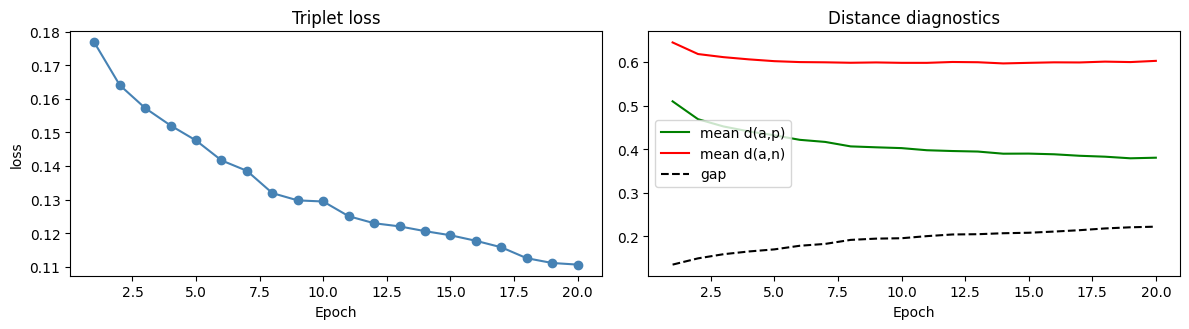

In [31]:
train_dataset = DogTripletDataset(
    multi_pets=train_pets,
    all_pet_imgs=pet_images,
    neg_pool=train_neg_pool,
    transform=train_tf,
    n_triplets=N_TRIPLETS,
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True,
)

optimizer = torch.optim.Adam(
    model.projector.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

train_history = []
best_loss        = float("inf")
patience_counter = 0

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss   = 0.0
    n_active     = 0
    n_total      = 0
    sum_d_ap     = 0.0
    sum_d_an     = 0.0

    for anchor, positive, neg_random in tqdm(train_loader, desc=f"[stage 2] Epoch {epoch+1}/{N_EPOCHS}"):
        anchor     = anchor.to(DEVICE)
        positive   = positive.to(DEVICE)
        neg_random = neg_random.to(DEVICE)

        emb_a = model(anchor)
        emb_p = model(positive)
        emb_n_pool = model(neg_random)

        # Semi-hard mining: replace each anchor's random negative with an informative one.
        with torch.no_grad():
            d_ap_mining = cosine_distance(emb_a, emb_p)
            chosen_idx  = semi_hard_negative_indices(emb_a, emb_n_pool, d_ap_mining, MARGIN)
        emb_n = emb_n_pool[chosen_idx]

        # Triplet margin loss with cosine distance.
        d_ap = cosine_distance(emb_a, emb_p)
        d_an = cosine_distance(emb_a, emb_n)
        per_sample_loss = F.relu(d_ap - d_an + MARGIN)
        loss = per_sample_loss.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Diagnostics
        epoch_loss += loss.item()
        n_active   += int((per_sample_loss > 0).sum().item())
        n_total    += per_sample_loss.size(0)
        sum_d_ap   += d_ap.detach().sum().item()
        sum_d_an   += d_an.detach().sum().item()

    avg_loss     = epoch_loss / len(train_loader)
    frac_active  = n_active / max(n_total, 1)
    mean_d_ap    = sum_d_ap / max(n_total, 1)
    mean_d_an    = sum_d_an / max(n_total, 1)

    train_history.append({
        "loss": avg_loss, "frac_active": frac_active,
        "mean_d_ap": mean_d_ap, "mean_d_an": mean_d_an,
    })
    print(
        f"  epoch {epoch+1}: loss={avg_loss:.4f}  active={frac_active:.1%}  "
        f"d(a,p)={mean_d_ap:.3f}  d(a,n)={mean_d_an:.3f}  gap={mean_d_an-mean_d_ap:+.3f}"
    )

    # Early stopping
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"[early-stop] No improvement for {EARLY_STOP_PATIENCE} epochs. Stopping.")
            break

# Loss + gap curves
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
xs = list(range(1, len(train_history) + 1))
axes[0].plot(xs, [h["loss"] for h in train_history], marker="o", color="steelblue")
axes[0].set_title("Triplet loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("loss")
axes[1].plot(xs, [h["mean_d_ap"]              for h in train_history], label="mean d(a,p)", color="green")
axes[1].plot(xs, [h["mean_d_an"]              for h in train_history], label="mean d(a,n)", color="red")
axes[1].plot(xs, [h["mean_d_an"]-h["mean_d_ap"] for h in train_history], label="gap", color="black", linestyle="--")
axes[1].set_title("Distance diagnostics"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


---
## 11 — 🧪 Evaluation: Rank-1, Rank-5, mAP

For each val dog (must have ≥ 2 photos), we hold out **one photo as the query** and
build a **multi-view gallery embedding** by averaging (then re-normalising) the
embeddings of all *other* photos of the same dog. This mimics what the production
backend does: every shelter dog's embedding is a stable centroid over its photos.

### Metrics

- **Rank-1**: was the correct dog the top-1 retrieval? (Strictest metric.)
- **Rank-5**: was it in the top 5? (More forgiving — useful when the user can scan a
  short list.)
- **mAP**: mean average precision. With one relevant doc per query, AP = 1/rank of the
  correct doc. Rewards good ranking even when not top-1.

### Reading the numbers
- Rank-1 ≥ 0.55 / Rank-5 ≥ 0.78 / mAP ≥ 0.62 → solid for a frozen CLIP + light projector.
- Below that → either the projector is undertrained (low loss but small d(a,n)−d(a,p)
  gap) or the val set is too small.


In [32]:
model.eval()


def embed_image(path: Path) -> np.ndarray:
    """Single-image embedding (eval transform). Returns a 1D L2-normed vector."""
    try:
        x = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            return model(x).cpu().numpy().flatten()
    except Exception:
        return np.zeros(EMBED_DIM, dtype="float32")


def mean_embed(paths: list[Path]) -> np.ndarray:
    """Multi-view aggregation: mean of per-image embeddings, then re-normalised."""
    embs = np.stack([embed_image(p) for p in paths])
    mean = embs.mean(axis=0)
    return (mean / (np.linalg.norm(mean) + 1e-9)).astype("float32")


# Build the gallery: one row per val dog, multi-view aggregated, query held out.
gallery_embs, gallery_ids, queries = [], [], []
for pid, imgs in val_pets.items():
    if len(imgs) < 2:
        continue
    query_path    = imgs[-1]                  # held out
    gallery_paths = imgs[:-1]                 # used to build centroid
    gallery_embs.append(mean_embed(gallery_paths))
    gallery_ids.append(pid)
    queries.append((pid, query_path))

gallery_embs = np.stack(gallery_embs).astype("float32")
faiss.normalize_L2(gallery_embs)

gal_index = faiss.IndexFlatIP(EMBED_DIM)
gal_index.add(gallery_embs)

# Run all queries.
rank1, rank5, ap_sum = 0, 0, 0.0
for pid, qpath in queries:
    q = embed_image(qpath).reshape(1, -1).astype("float32")
    faiss.normalize_L2(q)
    _, I = gal_index.search(q, len(gallery_ids))
    ranks = [gallery_ids[idx] for idx in I[0]]
    if ranks[0] == pid:           rank1 += 1
    if pid in ranks[:5]:          rank5 += 1
    if pid in ranks:              ap_sum += 1.0 / (ranks.index(pid) + 1)

n = len(queries)
print(f"Val queries: {n}")
print(f"Rank-1: {rank1/n:.1%}  ({rank1}/{n})")
print(f"Rank-5: {rank5/n:.1%}  ({rank5}/{n})")
print(f"mAP:    {ap_sum/n:.3f}")


Val queries: 909
Rank-1: 61.1%  (555/909)
Rank-5: 80.4%  (731/909)
mAP:    0.696


---
## 12 — 🚀 Export (FAISS-compatible artefacts)

We export exactly what the existing chatbot backend (`backend/tools/dog_finder.py`)
expects — same file names, same shapes:

| File | Contents | Shape |
|---|---|---|
| `dog_encoder.pt`   | Projector `state_dict()` only (CLIP weights are public, no need to ship) | — |
| `dog_emb_reid.npy` | Multi-view aggregated embeddings of every dog in `pet_images` | `(N, 256)` float32 |
| `dog_ids_reid.npy` | PetID array aligned with the embeddings | `(N,)` object |

> Backward compatibility note: only the embedding *dimension* changed
> (128 → 256). The backend's `SIAMESE_DIM = 256` was updated in lock-step.
> Inference logic, FAISS index type (`IndexFlatIP`), file layout — all unchanged.


In [33]:
OUTPUT = Path(OUTPUT_DIR)
OUTPUT.mkdir(exist_ok=True, parents=True)

# 1. Projector weights (the only trainable component).
torch.save(model.projector.state_dict(), OUTPUT / "dog_encoder.pt")
print(f"dog_encoder.pt saved: {(OUTPUT / 'dog_encoder.pt').stat().st_size/1024:.1f} KB")

# 2. Multi-view embeddings for every PetFinder dog (train + val + single-image dogs).
all_dog_embs, all_dog_ids = [], []
for pid, imgs in tqdm(pet_images.items(), desc="Embedding shelter gallery"):
    emb = mean_embed(imgs) if len(imgs) >= 2 else embed_image(imgs[0])
    all_dog_embs.append(emb)
    all_dog_ids.append(pid)

all_dog_embs = np.stack(all_dog_embs).astype("float32")
np.save(OUTPUT / "dog_emb_reid.npy", all_dog_embs)
np.save(OUTPUT / "dog_ids_reid.npy", np.array(all_dog_ids, dtype=object))

print(f"dog_emb_reid.npy: shape {all_dog_embs.shape}")
print(f"dog_ids_reid.npy: {len(all_dog_ids)} ids")


dog_encoder.pt saved: 1550.9 KB


Embedding shelter gallery:   0%|          | 0/7938 [00:00<?, ?it/s]

dog_emb_reid.npy: shape (7938, 256)
dog_ids_reid.npy: 7938 ids


---
## 13 — Verification

Sanity-checks the artefacts before you download them. If anything fails, re-run the
relevant section above before trusting the export.


In [34]:
REQUIRED = ["dog_encoder.pt", "dog_emb_reid.npy", "dog_ids_reid.npy"]

ok = True
for name in REQUIRED:
    p = OUTPUT / name
    if not p.exists() or p.stat().st_size == 0:
        print(f"FAIL  {name}  (missing or empty)")
        ok = False
    else:
        print(f"OK    {name:25s}  {p.stat().st_size/1024**2:7.2f} MB")

# Shape consistency
emb = np.load(OUTPUT / "dog_emb_reid.npy")
ids = np.load(OUTPUT / "dog_ids_reid.npy", allow_pickle=True)
assert emb.shape[0] == len(ids), f"mismatch: {emb.shape[0]} embs vs {len(ids)} ids"
assert emb.shape[1] == EMBED_DIM, f"embedding dim {emb.shape[1]} != EMBED_DIM={EMBED_DIM}"

# Norms — embeddings should be ~unit-length (we re-normalise after the mean).
norms = np.linalg.norm(emb, axis=1)
print(f"\nEmbedding norms: mean={norms.mean():.3f}  std={norms.std():.3f}  (expect ~1.0)")

print("\nAll dog-finder artefacts OK." if ok else "\nFix the issues above before downloading.")


OK    dog_encoder.pt                1.51 MB
OK    dog_emb_reid.npy              7.75 MB
OK    dog_ids_reid.npy              0.09 MB

Embedding norms: mean=1.000  std=0.000  (expect ~1.0)

All dog-finder artefacts OK.
